<a href="https://colab.research.google.com/github/Odewenu/network-anomaly-detection/blob/main/notebooks/02_model_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 2: Model Training
Anomaly Detection in Network Traffic (UNSW-NB15)

Goal: train a model that separates normal traffic from attacks, tune it, test it, and save it for deployment.

## 1. Imports
Install xgboost and load the libraries used in this notebook.

In [1]:
# Install xgboost and import the libraries we need
!pip install -q xgboost
import os, json, time, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, classification_report,
                             ConfusionMatrixDisplay, RocCurveDisplay)
from xgboost import XGBClassifier

SEED = 42   # fixed seed so results can be repeated

## 2. Load cleaned data
Load the train and test files saved at the end of Phase 1.

In [2]:
# Load the cleaned train and test files from Phase 1 (clone the repo if they are missing)
if not os.path.exists("data/processed/train_clean.parquet"):
    !git clone https://github.com/Odewenu/network-anomaly-detection.git
    %cd network-anomaly-detection

train = pd.read_parquet("data/processed/train_clean.parquet")
test = pd.read_parquet("data/processed/test_clean.parquet")

# Split into inputs (X) and the label we want to predict (y): 0 = normal, 1 = attack
X_full, y_full = train.drop(columns="label"), train["label"]
X_test, y_test = test.drop(columns="label"), test["label"]
print(X_full.shape, X_test.shape)

Cloning into 'network-anomaly-detection'...
remote: Enumerating objects: 130, done.
remote: Counting objects: 100% (130/130), done.
remote: Compressing objects: 100% (123/123), done.
remote: Total 130 (delta 41), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (130/130), 14.47 MiB | 21.29 MiB/s, done.
Resolving deltas: 100% (41/41), done.
/content/network-anomaly-detection
(96822, 65) (48400, 65)


## 3. Train/validation split
The test set is kept aside until the final evaluation.

In [3]:
# Hold out 20% of train as a validation set (stratify keeps the normal/attack ratio the same)
X_train, X_val, y_train, y_val = train_test_split(
    X_full, y_full, test_size=0.2, stratify=y_full, random_state=SEED)
print(X_train.shape, X_val.shape)

(77457, 65) (19365, 65)


## 4. Evaluation helper
Recall matters most here because a missed attack costs more than a false alarm.

In [4]:
# One function so every model is scored the same way
def evaluate(model, X, y, name):
    pred = model.predict(X)    # 0 or 1
    score = model.predict_proba(X)[:, 1] if hasattr(model, "predict_proba") else pred    # chance of attack
    return {"model": name,
            "accuracy": accuracy_score(y, pred),
            "precision": precision_score(y, pred),
            "recall": recall_score(y, pred),
            "f1": f1_score(y, pred),
            "roc_auc": roc_auc_score(y, score),
            "pr_auc": average_precision_score(y, score)}

## 5. Baseline models (validation set)
Train four standard models with sensible settings and compare them.

In [5]:
# Train four baseline models and score them on the validation set
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=SEED),
    "Decision Tree": DecisionTreeClassifier(max_depth=12, random_state=SEED),
    "Random Forest": RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=SEED),
    "XGBoost": XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=6,
                             eval_metric="logloss", random_state=SEED, n_jobs=-1),
}

rows = []
for name, m in models.items():
    t0 = time.time()    # time how long training takes
    m.fit(X_train, y_train)
    r = evaluate(m, X_val, y_val, name)
    r["seconds"] = round(time.time() - t0, 1)
    rows.append(r)

# Put the scores in a table, best F1 first
baseline = pd.DataFrame(rows).set_index("model").round(4).sort_values("f1", ascending=False)
baseline

,accuracy,precision,recall,f1,roc_auc,pr_auc,seconds
model,,,,,,,
XGBoost,0.9269,0.9085,0.9477,0.9277,0.9844,0.9828,6.3
Random Forest,0.9243,0.9080,0.9426,0.9250,0.9832,0.9814,55.0
Decision Tree,0.9139,0.8704,0.9707,0.9178,0.9747,0.9658,2.9
Logistic Regression,0.8733,0.8310,0.9341,0.8795,0.9299,0.9165,10.6


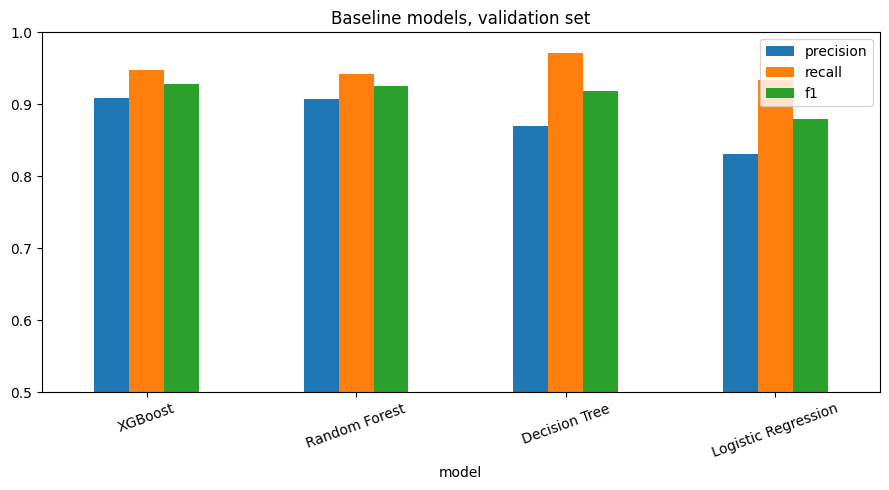

In [6]:
# Chart the comparison (saved for the report)
baseline[["precision", "recall", "f1"]].plot(kind="bar", figsize=(9, 5), ylim=(0.5, 1))
plt.title("Baseline models, validation set")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("baseline_comparison.png", dpi=150)
plt.show()

## 6. Isolation Forest (trained on normal traffic only)
An unsupervised model that never sees attack labels, used for comparison with the supervised models.

In [7]:
# Keep only the NORMAL rows (label 0) from the training part
X_normal_only = X_train[y_train == 0]

iso = IsolationForest(
    n_estimators=200,        # number of trees
    contamination=0.05,      # assumed share of anomalies in the data
    random_state=SEED,
    n_jobs=-1,
)
iso.fit(X_normal_only)       # learn what normal traffic looks like

# IsolationForest says -1 for anomaly and 1 for normal, so we convert to 1 (attack) / 0 (normal)
iso_pred = (iso.predict(X_val) == -1).astype(int)
iso_score = -iso.score_samples(X_val)     # higher value = more unusual

iso_result = {
    "model": "Isolation Forest (unsupervised)",
    "accuracy": accuracy_score(y_val, iso_pred),
    "precision": precision_score(y_val, iso_pred),
    "recall": recall_score(y_val, iso_pred),
    "f1": f1_score(y_val, iso_pred),
    "roc_auc": roc_auc_score(y_val, iso_score),
    "pr_auc": average_precision_score(y_val, iso_score),
}
pd.DataFrame([iso_result]).set_index("model").round(4)

,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,
Isolation Forest (unsupervised),0.58,0.8,0.202,0.3225,0.6954,0.6833


## 7. Hyperparameter tuning (XGBoost)
Search for better settings on the training data only. This can take a few minutes.

In [8]:
# Search for better XGBoost settings: 20 random combinations, 3-fold cross-validation, scored on F1
params = {
    "n_estimators": [200, 300, 500],
    "max_depth": [4, 6, 8, 10],
    "learning_rate": [0.03, 0.05, 0.1, 0.2],
    "subsample": [0.7, 0.85, 1.0],
    "colsample_bytree": [0.7, 0.85, 1.0],
    "min_child_weight": [1, 3, 5],
}
search = RandomizedSearchCV(
    XGBClassifier(eval_metric="logloss", random_state=SEED, n_jobs=-1),
    params, n_iter=20, scoring="f1",
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED),
    random_state=SEED, n_jobs=-1, verbose=1)
search.fit(X_train, y_train)

# Best settings found, and how the tuned model does on the validation set
print(search.best_params_)
print("CV F1:", round(search.best_score_, 4))
print(evaluate(search.best_estimator_, X_val, y_val, "XGBoost (tuned)"))

Fitting 3 folds for each of 20 candidates, totalling 60 fits
{'subsample': 0.85, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 0.85}
CV F1: 0.9249
{'model': 'XGBoost (tuned)', 'accuracy': 0.926000516395559, 'precision': 0.9071207430340558, 'recall': 0.9475276444815356, 'f1': 0.9268840246951375, 'roc_auc': np.float64(0.9846204286012339), 'pr_auc': np.float64(0.9835173691507765)}


## 8. Final evaluation on the test set
The test set is used only now, after the model has been chosen.

In [9]:
# Retrain the tuned model on all training data, then score it on the test set (used once)
final_model = XGBClassifier(**search.best_params_, eval_metric="logloss", random_state=SEED, n_jobs=-1)
final_model.fit(X_full, y_full)

final_metrics = evaluate(final_model, X_test, y_test, "XGBoost (final)")
test_pred = final_model.predict(X_test)

print(pd.Series(final_metrics).round(4))
print(classification_report(y_test, test_pred, target_names=["Normal", "Attack"]))

model        XGBoost (final)
accuracy            0.827665
precision           0.688649
recall              0.946679
f1                  0.797307
roc_auc             0.961784
pr_auc              0.944954
dtype: object
              precision    recall  f1-score   support

      Normal       0.96      0.76      0.85     31071
      Attack       0.69      0.95      0.80     17329

    accuracy                           0.83     48400
   macro avg       0.83      0.85      0.82     48400
weighted avg       0.86      0.83      0.83     48400



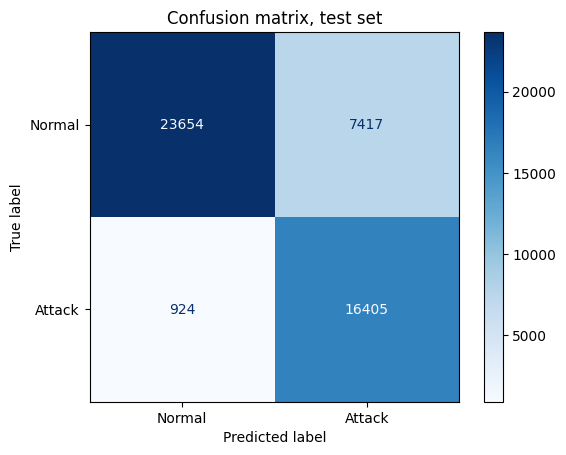

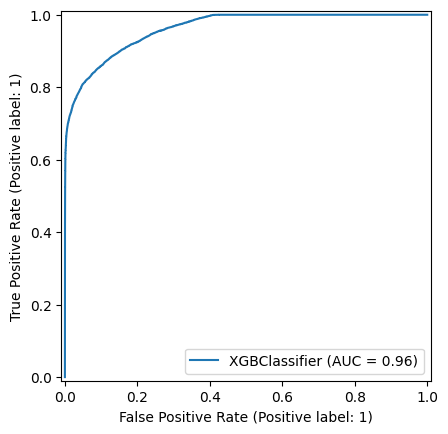

In [10]:
# Confusion matrix and ROC curve for the test set
ConfusionMatrixDisplay.from_predictions(y_test, test_pred, display_labels=["Normal", "Attack"], cmap="Blues")
plt.title("Confusion matrix, test set")
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

RocCurveDisplay.from_estimator(final_model, X_test, y_test)
plt.savefig("roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

### All models on the test set (for the report table)
The model was chosen on validation scores, so this table is for reporting only.

In [11]:
# Score every model on the test set for the report table (retrained on all training data)
test_rows = []
for name, m in models.items():
    f = clone(m).fit(X_full, y_full)
    test_rows.append(evaluate(f, X_test, y_test, name + " (untuned)"))
test_rows.append(final_metrics)

# Isolation Forest, again on normal traffic only
iso_full = IsolationForest(n_estimators=200, contamination=0.05, random_state=SEED, n_jobs=-1)
iso_full.fit(X_full[y_full == 0])
p = (iso_full.predict(X_test) == -1).astype(int)
s = -iso_full.score_samples(X_test)
test_rows.append({"model": "Isolation Forest", "accuracy": accuracy_score(y_test, p),
                  "precision": precision_score(y_test, p), "recall": recall_score(y_test, p),
                  "f1": f1_score(y_test, p), "roc_auc": roc_auc_score(y_test, s),
                  "pr_auc": average_precision_score(y_test, s)})

test_comparison = pd.DataFrame(test_rows).set_index("model").round(4).sort_values("f1", ascending=False)
test_comparison.to_csv("test_comparison_all_models.csv")
test_comparison

,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,
XGBoost (untuned),0.8289,0.6919,0.9414,0.7976,0.9615,0.9447
XGBoost (final),0.8277,0.6886,0.9467,0.7973,0.9618,0.9450
Random Forest (untuned),0.8283,0.6918,0.9385,0.7965,0.9574,0.9318
Decision Tree (untuned),0.7810,0.6268,0.9601,0.7584,0.9418,0.8870
Logistic Regression (untuned),0.7120,0.5612,0.8976,0.6906,0.8270,0.7275
Isolation Forest,0.6735,0.6498,0.1909,0.2951,0.6510,0.5114


## 9. Detection rate per attack type
Shows which attack types the model catches and which it misses.

In [12]:
# Check how many of each attack type the model catches (attack_cat was saved in Phase 1, not used for training)
cats = pd.read_parquet("data/processed/test_attack_cat.parquet")["attack_cat"].values

rows = []
for c in sorted(set(cats) - {"Normal"}):
    mask = cats == c
    rows.append({"attack_type": c, "samples": int(mask.sum()),
                 "detected_%": round((test_pred[mask] == 1).mean() * 100, 2)})

per_attack = pd.DataFrame(rows).sort_values("detected_%")
per_attack.to_csv("per_attack_detection.csv", index=False)
per_attack

,attack_type,samples,detected_%
4,Fuzzers,4231,82.44
7,Shellcode,303,94.39
3,Exploits,7389,98.39
2,DoS,1504,98.54
1,Backdoor,268,99.25
6,Reconnaissance,2012,99.30
5,Generic,1257,99.52
0,Analysis,323,99.69
8,Worms,42,100.00


## 10. Feature importance
Shows which traffic features drive the predictions.

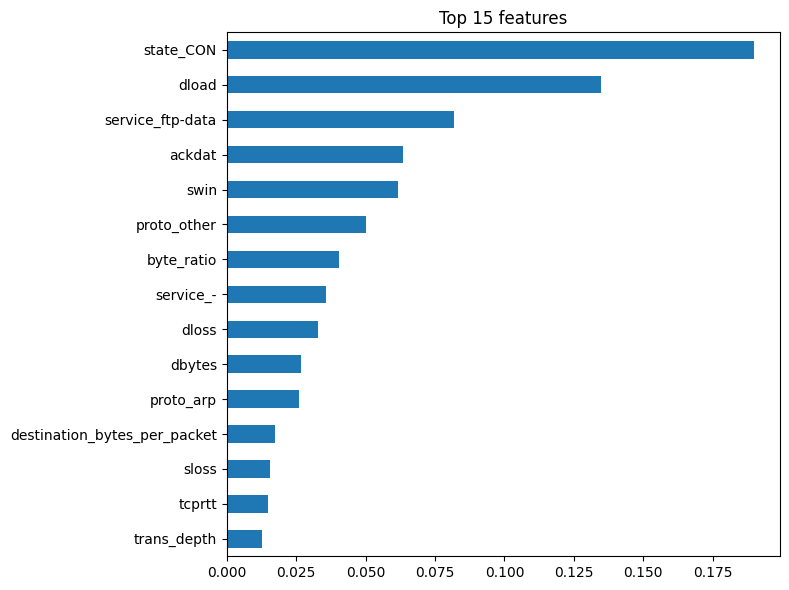

In [13]:
# Show the 15 features the model relies on most
imp = pd.Series(final_model.feature_importances_, index=X_full.columns).sort_values(ascending=False).head(15)
imp.iloc[::-1].plot(kind="barh", figsize=(8, 6), title="Top 15 features")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

## 11. Save model and artifacts
Files to push to GitHub and use in Phase 3.

In [14]:
# Save the model and the files Phase 3 (deployment) needs
os.makedirs("models", exist_ok=True)
joblib.dump(final_model, "models/xgb_model.pkl")

# Column names in order: the deployed app must give the model inputs in this exact order
json.dump(list(X_full.columns), open("models/feature_columns.json", "w"))
json.dump({k: v if isinstance(v, str) else float(v) for k, v in final_metrics.items()},
          open("models/test_metrics.json", "w"), indent=2)
json.dump({k: float(v) if isinstance(v, float) else int(v) for k, v in search.best_params_.items()},
          open("models/best_params.json", "w"), indent=2)
baseline.to_csv("models/baseline_comparison.csv")

# Reload the saved model and check it gives the same predictions
reloaded = joblib.load("models/xgb_model.pkl")
print("reload check:", (reloaded.predict(X_test) == test_pred).all())

reload check: True


## 12. Training vs validation scores

In [15]:
# Score the baseline models on the TRAINING part and compare with the validation part
rows = []
for name, m in models.items():
    tr = evaluate(m, X_train, y_train, name)
    va = evaluate(m, X_val, y_val, name)
    rows.append({"model": name,
                 "train_accuracy": tr["accuracy"], "val_accuracy": va["accuracy"],
                 "train_f1": tr["f1"], "val_f1": va["f1"],
                 "f1_gap": tr["f1"] - va["f1"]})    # gap = how much better it does on data it has seen

train_vs_val = pd.DataFrame(rows).set_index("model").round(4).sort_values("val_f1", ascending=False)
train_vs_val.to_csv("train_vs_validation.csv")
train_vs_val

,train_accuracy,val_accuracy,train_f1,val_f1,f1_gap
model,,,,,
XGBoost,0.9505,0.9269,0.9508,0.9277,0.0231
Random Forest,0.9977,0.9243,0.9977,0.9250,0.0727
Decision Tree,0.9146,0.9139,0.9184,0.9178,0.0006
Logistic Regression,0.8713,0.8733,0.8776,0.8795,-0.0019


## 13. Learning curves for XGBoost

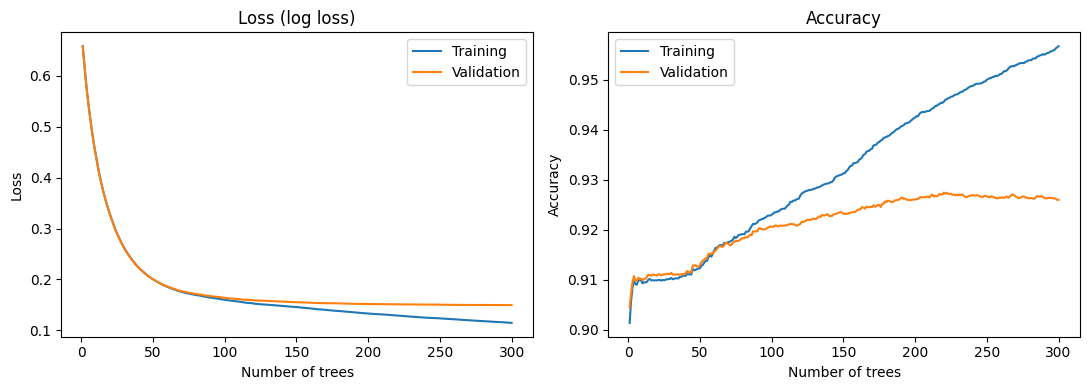

Final training loss / accuracy:   0.1148 / 0.9568
Final validation loss / accuracy: 0.1497 / 0.926
Validation loss was lowest at tree number: 295 of 300


In [16]:
# Re-train the tuned XGBoost on the training part and record loss and error after every tree
curve_model = XGBClassifier(**search.best_params_, eval_metric=["logloss", "error"], random_state=SEED, n_jobs=-1)
curve_model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_val, y_val)], verbose=False)
history = curve_model.evals_result()

train_loss = np.array(history["validation_0"]["logloss"])
val_loss = np.array(history["validation_1"]["logloss"])
train_acc = 1 - np.array(history["validation_0"]["error"])    # accuracy = 1 - error
val_acc = 1 - np.array(history["validation_1"]["error"])
trees = np.arange(1, len(train_loss) + 1)

# Two charts: loss on the left, accuracy on the right
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(trees, train_loss, label="Training")
ax[0].plot(trees, val_loss, label="Validation")
ax[0].set_title("Loss (log loss)")
ax[0].set_xlabel("Number of trees")
ax[0].set_ylabel("Loss")
ax[0].legend()
ax[1].plot(trees, train_acc, label="Training")
ax[1].plot(trees, val_acc, label="Validation")
ax[1].set_title("Accuracy")
ax[1].set_xlabel("Number of trees")
ax[1].set_ylabel("Accuracy")
ax[1].legend()
plt.tight_layout()
plt.savefig("learning_curves.png", dpi=150)
plt.show()

# Numbers to quote in the report
print("Final training loss / accuracy:  ", round(train_loss[-1], 4), "/", round(train_acc[-1], 4))
print("Final validation loss / accuracy:", round(val_loss[-1], 4), "/", round(val_acc[-1], 4))
print("Validation loss was lowest at tree number:", int(val_loss.argmin()) + 1, "of", len(val_loss))

## 14. Failure analysis
Part 1 shows where the false alarms happen. Part 2 compares the Fuzzers the model caught with the ones it missed.

In [17]:
# Part 1: false alarm rate inside each protocol, service and connection state (normal traffic only)
results = X_test.copy()
results["true"] = y_test.values
results["pred"] = test_pred
normal = results[results["true"] == 0]
print("Overall false alarm rate:", round((normal["pred"] == 1).mean() * 100, 1), "%")

rows = []
for col in [c for c in X_test.columns if c.startswith(("proto_", "service_", "state_"))]:
    group = normal[normal[col] == 1]
    if len(group) >= 100:    # skip very small groups, their rates are not reliable
        rows.append({"group": col, "normal_records": len(group),
                     "false_alarm_%": round((group["pred"] == 1).mean() * 100, 1)})

fa_table = pd.DataFrame(rows).sort_values("false_alarm_%", ascending=False)
fa_table.to_csv("false_alarms_by_group.csv", index=False)
fa_table.head(10)

Overall false alarm rate: 23.9 %


,group,normal_records,false_alarm_%
12,state_INT,1263,79.4
5,service_ftp,752,38.0
7,service_http,3722,34.7
11,state_FIN,23366,27.3
3,service_-,22206,26.2
1,proto_tcp,25649,25.0
2,proto_udp,5253,19.0
13,state_REQ,330,3.3
4,service_dns,2611,0.6
10,state_CON,6109,0.3


In [18]:
# Part 2: compare caught Fuzzers, missed Fuzzers and normal traffic on the 5 most important features
# (values are standardised in Phase 1: 0 = average, positive = above average, negative = below average)
cats = pd.read_parquet("data/processed/test_attack_cat.parquet")["attack_cat"].values
fuzz = results[cats == "Fuzzers"]
top5 = pd.Series(final_model.feature_importances_, index=X_full.columns).sort_values(ascending=False).head(5).index

fuzzer_comparison = pd.DataFrame({
    "caught_fuzzers": fuzz[fuzz["pred"] == 1][top5].mean(),
    "missed_fuzzers": fuzz[fuzz["pred"] == 0][top5].mean(),
    "normal_traffic": normal[top5].mean(),
}).round(2)
fuzzer_comparison.to_csv("fuzzer_comparison.csv")
fuzzer_comparison

,caught_fuzzers,missed_fuzzers,normal_traffic
state_CON,0.00,0.00,0.20
dload,-0.38,-0.38,0.13
service_ftp-data,0.00,0.00,0.03
ackdat,0.45,0.48,0.08
swin,-0.02,0.30,0.10
